# 1. Compute normalized performance

- This notebook visualizes results from experiment `experiments/exp_length_generalization.sh`.

Names of models:
- GPT
- SB-GPT
- SB-GPT + time
- UT
- UT (2-phase)
- UT (nested)
- TRM

---

# Base functions

In [1]:

import argparse
import os
from collections import defaultdict
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import wandb

# =============================================================================
# Configuration
# =============================================================================

DATA_DIR = "/mnt/pdata/pr501/icml2025"
WANDB_PROJECT = "pauliusrauba/icml-recursive-llms"

# Style settings for publication-quality figures
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'legend.fontsize': 10,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'figure.figsize': (10, 6),
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

# Color palette for models (colorblind-friendly)
MODEL_COLORS = {
    'gpt': '#1f77b4',        # Blue
    'gpt_level1': '#ff7f0e',  # Orange
    'gpt_level2': '#2ca02c',  # Green
    'ut': '#d62728',          # Red
    'ut_level1': '#9467bd',   # Purple
    'ut_level2': '#8c564b',   # Brown
    'trm': '#e377c2',         # Pink
}

MODEL_LABELS = {
    'gpt': 'GPT',
    'gpt_level1': 'GPT-L1',
    'gpt_level2': 'GPT-L2',
    'ut': 'UT',
    'ut_level1': 'UT-L1',
    'ut_level2': 'UT-L2',
    'trm': 'TRM',
}

MODEL_ORDER = ['gpt', 'gpt_level1', 'gpt_level2', 'ut', 'ut_level1', 'ut_level2', 'trm']

TASK_LABELS = {
    'addition': 'Addition',
    'copy': 'Copy',
    'reverse': 'Reverse',
}

LINE_STYLES = {
    'gpt': '-',
    'gpt_level1': '-',
    'gpt_level2': '-',
    'ut': '--',
    'ut_level1': '--',
    'ut_level2': '--',
    'trm': '--',
}

MARKERS = {
    'gpt': 'o',
    'gpt_level1': 's',
    'gpt_level2': '^',
    'ut': 'o',
    'ut_level1': 's',
    'ut_level2': '^',
    'trm': 'D',
}


# =============================================================================
# Data Fetching
# =============================================================================

def fetch_runs(tag_filter: str) -> List:
    """Fetch all runs matching the tag filter from W&B."""
    api = wandb.Api()
    runs = api.runs(WANDB_PROJECT)
    filtered_runs = [r for r in runs if tag_filter in r.name and r.state == "finished"]
    print(f"Found {len(filtered_runs)} finished runs matching '{tag_filter}'")
    return filtered_runs


def parse_run_name(run_name: str) -> Tuple[str, str]:
    """Extract model and task from run name like 'gpt_addition_char_lengthgen_train10_compute24'."""
    parts = run_name.split('_')
    
    # Find task (addition, copy, reverse)
    task = None
    task_idx = None
    for i, part in enumerate(parts):
        if part in ('addition', 'copy', 'reverse'):
            task = part
            task_idx = i
            break
    
    if task is None:
        return None, None
    
    # Model is everything before the task
    model = '_'.join(parts[:task_idx])
    
    return model, task


def extract_final_metrics(run) -> Dict:
    """Extract final metrics from a run's summary."""
    config = run.config
    summary = run.summary._json_dict
    
    model, task = parse_run_name(run.name)
    if model is None:
        return None
    
    train_len = config.get('algo_train_len', 10)
    
    # Extract metrics for each evaluation length
    result = {
        'run_name': run.name,
        'model': model,
        'task': task,
        'train_len': train_len,
        'param_count_M': summary.get('model/param_count_M', 0),
        'compute_budget': config.get('compute_budget', 24),
    }
    
    # Find all evaluation lengths from the summary keys
    eval_lengths = set()
    for key in summary.keys():
        if key.startswith(f'TaskEvaluation/{task}/L'):
            # Extract length from key like 'TaskEvaluation/addition/L10/seq_acc'
            parts = key.split('/')
            if len(parts) >= 3:
                length_str = parts[2]  # 'L10'
                if length_str.startswith('L'):
                    try:
                        length = int(length_str[1:])
                        eval_lengths.add(length)
                    except ValueError:
                        pass
    
    # Extract metrics for each length
    for length in sorted(eval_lengths):
        prefix = f'TaskEvaluation/{task}/L{length}'
        result[f'L{length}_seq_acc'] = summary.get(f'{prefix}/seq_acc', None)
        result[f'L{length}_char_acc'] = summary.get(f'{prefix}/char_acc', None)
        result[f'L{length}_ratio'] = length / train_len
    
    result['eval_lengths'] = sorted(eval_lengths)
    
    return result


def extract_training_curves(run) -> pd.DataFrame:
    """Extract training curves with step-by-step metrics for FLOPs analysis."""
    config = run.config
    model, task = parse_run_name(run.name)
    
    if model is None:
        return None
    
    train_len = config.get('algo_train_len', 10)
    batch_size = config.get('batch_size', 64)
    block_size = config.get('block_size', 180)
    compute_budget = config.get('compute_budget', 24)
    
    # Get history
    try:
        history = run.history(pandas=True, samples=10000)
    except Exception as e:
        print(f"  Warning: Could not fetch history for {run.name}: {e}")
        return None
    
    if history.empty:
        return None
    
    # Get param count - prefer from history column, fallback to summary
    param_count_M = None
    if 'model/param_count_M' in history.columns:
        valid_params = history['model/param_count_M'].dropna()
        if not valid_params.empty:
            param_count_M = valid_params.iloc[0]
    if param_count_M is None:
        param_count_M = run.summary._json_dict.get('model/param_count_M', 0)
    
    # Build dataframe with metrics at each step
    records = []
    
    # Find all length-specific metrics in the history
    eval_lengths = set()
    for col in history.columns:
        if col.startswith(f'TaskEvaluation/{task}/L'):
            parts = col.split('/')
            if len(parts) >= 3:
                length_str = parts[2]
                if length_str.startswith('L'):
                    try:
                        length = int(length_str[1:])
                        eval_lengths.add(length)
                    except ValueError:
                        pass
    
    for idx, row in history.iterrows():
        step = row.get('_step', idx)
        if pd.isna(step):
            continue
        
        step = int(step)
        if step == 0:
            continue  # Skip step 0 (sanity check)
        
        # Tokens processed
        tokens_processed = step * batch_size * block_size
        # Line ~192-196
        n_embd = config.get('n_embd', 256)

        # Exact params per Block (from models/common/layers.py):
        # - Attention: 3*n_embd² (QKV, no bias) + n_embd² + n_embd (proj with bias)
        # - FFN: 4*n_embd² + 4*n_embd (fc1) + 4*n_embd² + n_embd (fc2)
        # - LayerNorms: 2 × 2*n_embd
        params_per_block = 12 * n_embd ** 2 + 10 * n_embd

        # Line ~247: Correct FLOPs
        flops = 6 * params_per_block * tokens_processed * compute_budget
        
        # Normalized compute: tokens * block_passes (same for all models at same step)
        # This allows fair comparison since all models have same block_passes
        normalized_compute = tokens_processed * compute_budget
        
        record = {
            'model': model,
            'task': task,
            'step': step,
            'train_len': train_len,
            'param_count_M': param_count_M,
            'compute_budget': compute_budget,
            'tokens_processed': tokens_processed,
            'flops': flops,
            'flops_1e15': flops / 1e15,  # PetaFLOPs
            'normalized_compute': normalized_compute,
            'normalized_compute_1e12': normalized_compute / 1e12,
            'train_loss': row.get('train_loss', None),
            'val_loss': row.get('val_loss', None),
        }
        
        # Add metrics for each evaluation length
        for length in eval_lengths:
            prefix = f'TaskEvaluation/{task}/L{length}'
            record[f'L{length}_seq_acc'] = row.get(f'{prefix}/seq_acc', None)
            record[f'L{length}_char_acc'] = row.get(f'{prefix}/char_acc', None)
        
        records.append(record)
    
    df = pd.DataFrame(records)
    if not df.empty:
        df['eval_lengths'] = [sorted(eval_lengths)] * len(df)
    
    return df


def fetch_all_data(tag_filter: str) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Fetch all data from W&B and return final metrics and training curves."""
    runs = fetch_runs(tag_filter)
    
    final_metrics = []
    training_curves = []
    
    for i, run in enumerate(runs):
        print(f"Processing run {i+1}/{len(runs)}: {run.name}")
        
        # Final metrics
        metrics = extract_final_metrics(run)
        if metrics:
            final_metrics.append(metrics)
        
        # Training curves
        curves = extract_training_curves(run)
        if curves is not None and not curves.empty:
            training_curves.append(curves)
    
    final_df = pd.DataFrame(final_metrics)
    curves_df = pd.concat(training_curves, ignore_index=True) if training_curves else pd.DataFrame()
    
    return final_df, curves_df


# Plots (Figs 1-4)

# Denote common markets and labels used

In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import wandb

# Configuration
DATA_DIR = "/mnt/pdata/pr501/icml2025"
WANDB_PROJECT = "pauliusrauba/icml-recursive-llms"
TAG_FILTER = "lengthgen_train10_compute24" 

# Style settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'legend.fontsize': 10,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'figure.figsize': (10, 6),
    'figure.dpi': 150,
})

# Model styling
MODEL_COLORS = {
    'gpt': '#1f77b4', 'gpt_level1': '#ff7f0e', 'gpt_level2': '#2ca02c',
    'ut': '#d62728', 'ut_level1': '#9467bd', 'ut_level2': '#8c564b', 'trm': '#e377c2',
}
MODEL_LABELS = {
    'gpt': 'GPT', 'gpt_level1': 'GPT-L1', 'gpt_level2': 'GPT-L2',
    'ut': 'UT', 'ut_level1': 'UT-L1', 'ut_level2': 'UT-L2', 'trm': 'TRM',
}
MODEL_ORDER = ['gpt', 'gpt_level1', 'gpt_level2', 'ut', 'ut_level1', 'ut_level2', 'trm']
TASK_LABELS = {'addition': 'Addition', 'copy': 'Copy', 'reverse': 'Reverse'}
LINE_STYLES = {
    'gpt': '-', 'gpt_level1': '-', 'gpt_level2': '-',
    'ut': '--', 'ut_level1': '--', 'ut_level2': '--', 'trm': '--',
}
MARKERS = {
    'gpt': 'o', 'gpt_level1': 's', 'gpt_level2': '^',
    'ut': 'o', 'ut_level1': 's', 'ut_level2': '^', 'trm': 'D',
}

## Set paths for uploading data

In [3]:
# Set paths
results_dir = os.path.join(DATA_DIR, 'results')
os.makedirs(results_dir, exist_ok=True)
csv_final = os.path.join(results_dir, f'final_metrics_{TAG_FILTER}.csv')
csv_curves = os.path.join(results_dir, f'training_curves_{TAG_FILTER}.csv')

# Check if CSVs exist - load from disk if available
if os.path.exists(csv_final) and os.path.exists(csv_curves):
    print(f"Loading existing data from {results_dir}")
    final_df = pd.read_csv(csv_final)
    curves_df = pd.read_csv(csv_curves)
    # Parse eval_lengths back to list
    if 'eval_lengths' in final_df.columns:
        final_df['eval_lengths'] = final_df['eval_lengths'].apply(eval)
else:
    # Fetch from W&B
    print(f"Fetching data from W&B with tag filter: {TAG_FILTER}")
    api = wandb.Api()
    runs = api.runs(WANDB_PROJECT)
    filtered_runs = [r for r in runs if TAG_FILTER in r.name and r.state == "finished"]
    print(f"Found {len(filtered_runs)} finished runs")
    
    final_metrics, training_curves = [], []
    for i, run in enumerate(filtered_runs):
        print(f"Processing run {i+1}/{len(filtered_runs)}: {run.name}")
        metrics = extract_final_metrics(run)
        if metrics:
            final_metrics.append(metrics)
        curves = extract_training_curves(run)
        if curves is not None and not curves.empty:
            training_curves.append(curves)
    
    final_df = pd.DataFrame(final_metrics)
    curves_df = pd.concat(training_curves, ignore_index=True) if training_curves else pd.DataFrame()
    
    # Save to CSV
    print(f"\nSaving data to {results_dir}")
    final_df.to_csv(csv_final, index=False)
    if not curves_df.empty:
        curves_df.to_csv(csv_curves, index=False)

print(f"\n=== Data Loaded ===")
print(f"final_df: {final_df.shape}, Models: {sorted(final_df['model'].unique())}, Tasks: {sorted(final_df['task'].unique())}")
print(f"curves_df: {curves_df.shape}")

Loading existing data from /mnt/pdata/pr501/icml2025/results

=== Data Loaded ===
final_df: (10, 22), Models: ['gpt', 'gpt_level1', 'gpt_level2', 'trm', 'ut', 'ut_level1', 'ut_level2'], Tasks: ['addition', 'copy']
curves_df: (1390, 24)


In [4]:
display(final_df.head())
print('---')
display(curves_df.head())

,run_name,model,task,train_len,param_count_M,compute_budget,L10_seq_acc,L10_char_acc,L10_ratio,L20_seq_acc,...,L30_seq_acc,L30_char_acc,L30_ratio,L40_seq_acc,L40_char_acc,L40_ratio,L50_seq_acc,L50_char_acc,L50_ratio,eval_lengths
0,gpt_addition_char_lengthgen_train10_compute24,gpt,addition,10,42.640142,24,0.02,0.799091,1.0,0,...,0,0.103548,3.0,0,0.096098,4.0,0,0.104510,5.0,"[10, 20, 30, 40, 50]"
1,gpt_level1_addition_char_lengthgen_train10_com...,gpt_level1,addition,10,1.853966,24,0.00,0.543636,1.0,0,...,0,0.103226,3.0,0,0.099756,4.0,0,0.101176,5.0,"[10, 20, 30, 40, 50]"
2,gpt_level2_addition_char_lengthgen_train10_com...,gpt_level2,addition,10,1.863182,24,0.00,0.558182,1.0,0,...,0,0.107742,3.0,0,0.114146,4.0,0,0.109804,5.0,"[10, 20, 30, 40, 50]"
3,ut_addition_char_lengthgen_train10_compute24,ut,addition,10,1.863567,24,0.00,0.658182,1.0,0,...,0,0.121290,3.0,0,0.114390,4.0,0,0.104510,5.0,"[10, 20, 30, 40, 50]"
4,ut_level1_addition_char_lengthgen_train10_comp...,ut_level1,addition,10,1.859727,24,0.03,0.834545,1.0,0,...,0,0.105161,3.0,0,0.104634,4.0,0,0.112353,5.0,"[10, 20, 30, 40, 50]"


---


,model,task,step,train_len,param_count_M,compute_budget,tokens_processed,flops,flops_1e15,normalized_compute,...,L40_char_acc,L10_seq_acc,L10_char_acc,L50_seq_acc,L50_char_acc,L20_seq_acc,L20_char_acc,L30_seq_acc,L30_char_acc,eval_lengths
0,gpt,addition,1,10,42.640142,24,11520,2941711810560,0.002942,276480,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[10, 20, 30, 40, 50]"
1,gpt,addition,2,10,42.640142,24,23040,5883423621120,0.005883,552960,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[10, 20, 30, 40, 50]"
2,gpt,addition,3,10,42.640142,24,34560,8825135431680,0.008825,829440,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[10, 20, 30, 40, 50]"
3,gpt,addition,4,10,42.640142,24,46080,11766847242240,0.011767,1105920,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[10, 20, 30, 40, 50]"
4,gpt,addition,5,10,42.640142,24,57600,14708559052800,0.014709,1382400,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[10, 20, 30, 40, 50]"


## Plot 1: Absolute length generalization

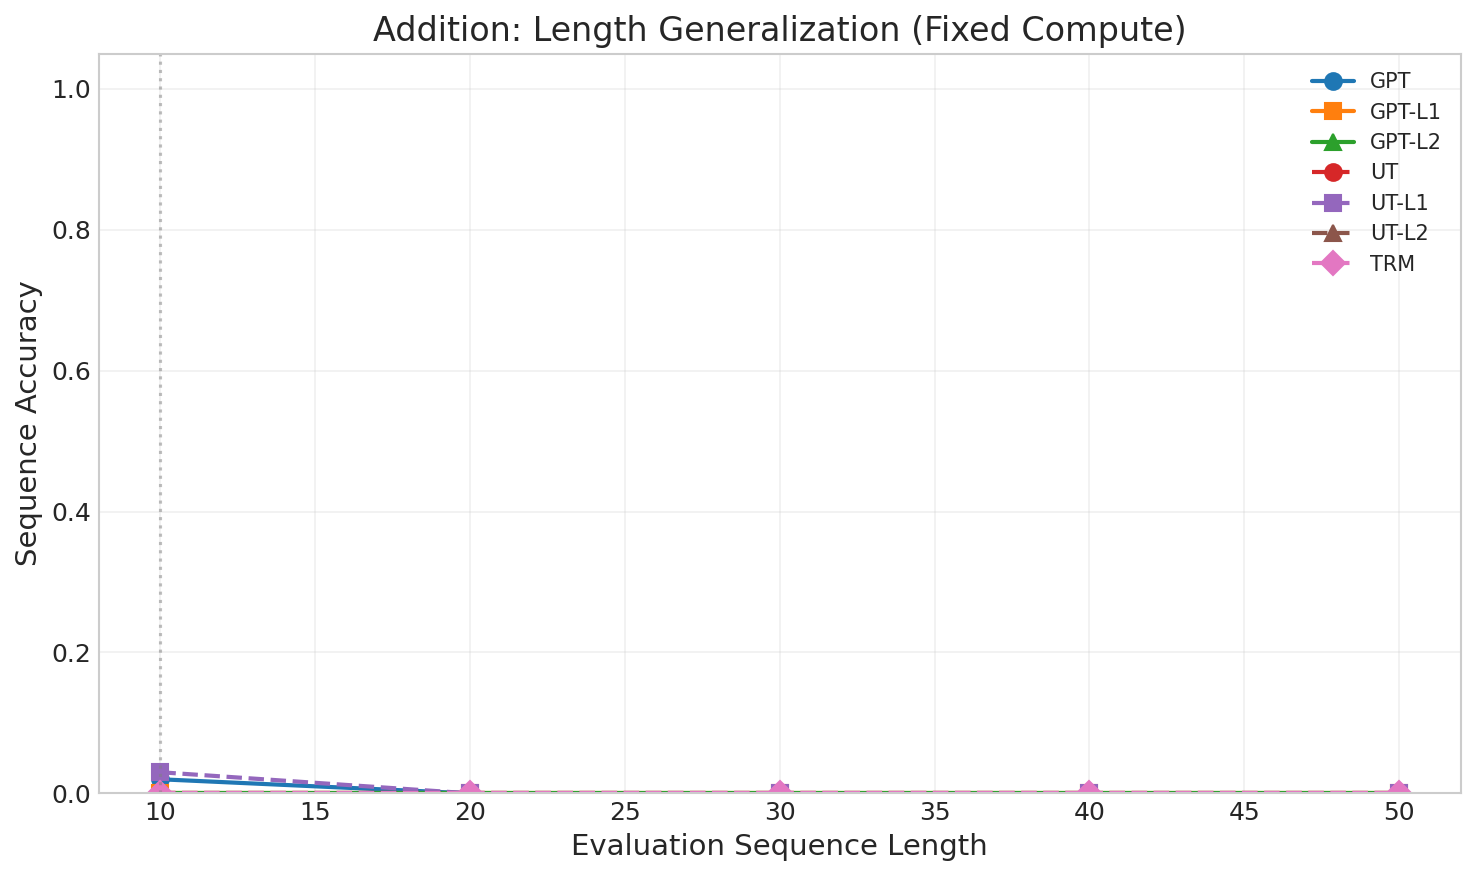

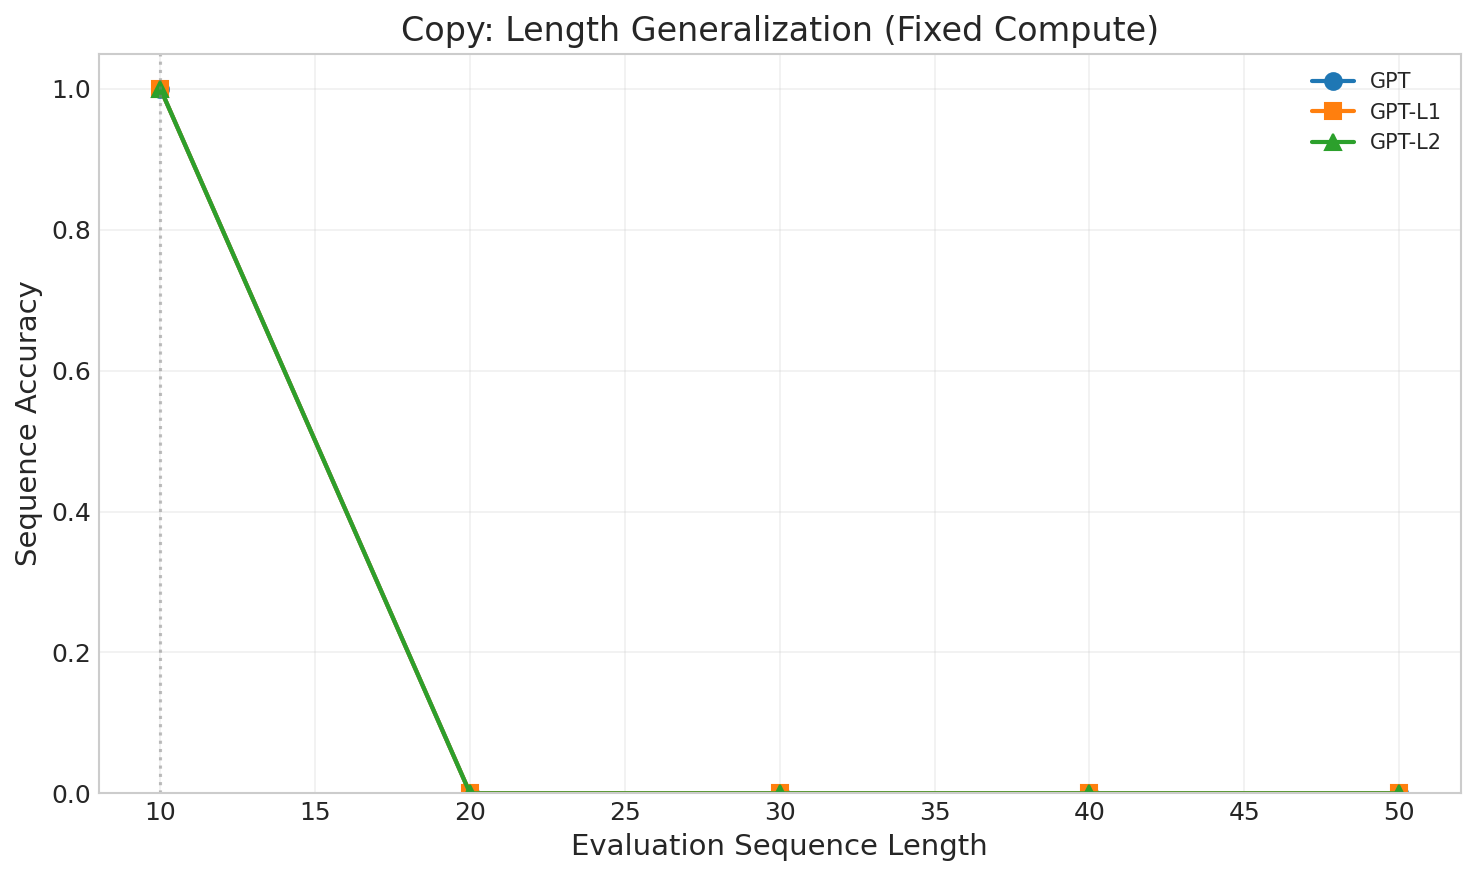

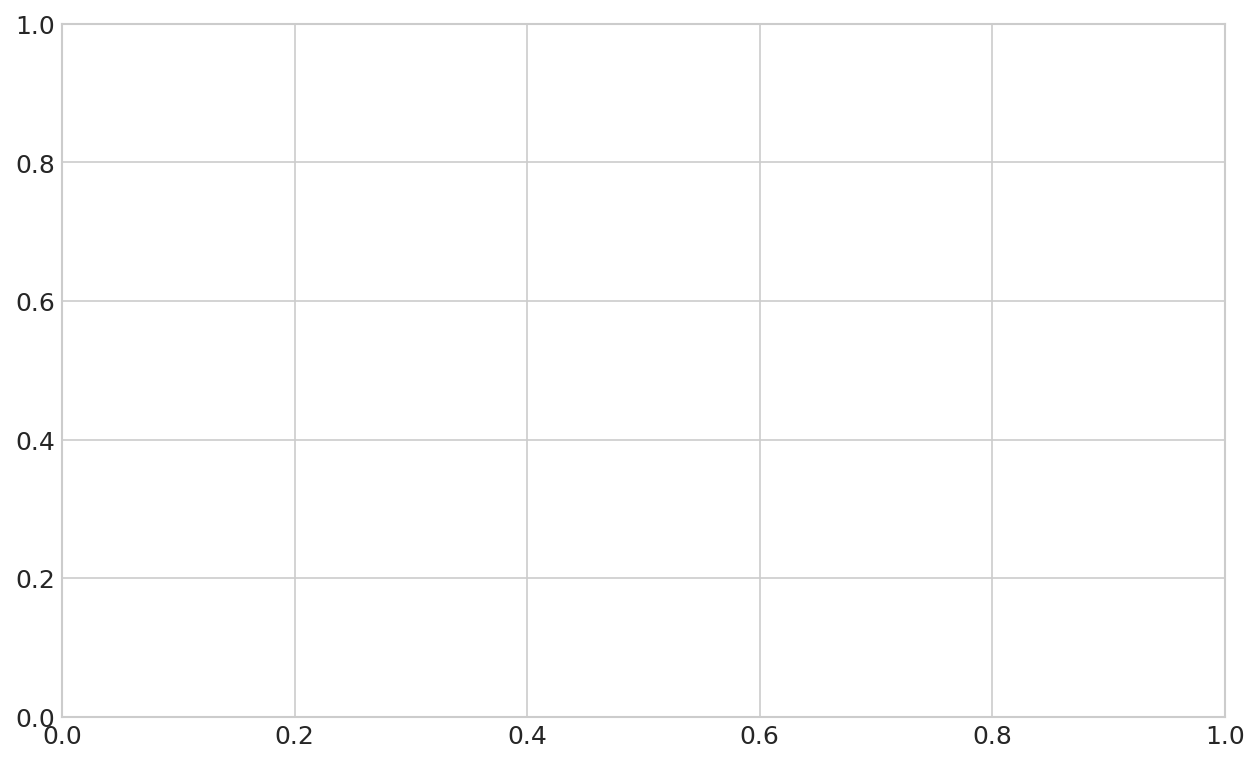

In [5]:
def plot_1_absolute_length(df: pd.DataFrame, task: str, metric: str = 'seq_acc') -> plt.Figure:
    """Plot 1: Absolute-length generalization at fixed inference compute."""
    fig, ax = plt.subplots(figsize=(10, 6))
    
    task_df = df[df['task'] == task].copy()
    if task_df.empty:
        print(f"Warning: No data for task {task}")
        return fig
    
    # Get eval lengths from columns
    eval_lengths = []
    for col in task_df.columns:
        if col.startswith('L') and col.endswith(f'_{metric}'):
            try:
                length = int(col.split('_')[0][1:])
                eval_lengths.append(length)
            except ValueError:
                pass
    eval_lengths = sorted(set(eval_lengths))
    
    for model in MODEL_ORDER:
        model_df = task_df[task_df['model'] == model]
        if model_df.empty:
            continue
        
        row = model_df.iloc[0]
        lengths, values = [], []
        
        for length in eval_lengths:
            col = f'L{length}_{metric}'
            if col in row and pd.notna(row[col]):
                lengths.append(length)
                values.append(row[col])
        
        if lengths:
            ax.plot(lengths, values, 
                    color=MODEL_COLORS.get(model, 'gray'),
                    linestyle=LINE_STYLES.get(model, '-'),
                    marker=MARKERS.get(model, 'o'),
                    markersize=8, linewidth=2,
                    label=MODEL_LABELS.get(model, model))
    
    ax.set_xlabel('Evaluation Sequence Length')
    ax.set_ylabel('Sequence Accuracy' if metric == 'seq_acc' else 'Character Accuracy')
    ax.set_title(f'{TASK_LABELS.get(task, task)}: Length Generalization (Fixed Compute)')
    ax.legend(loc='best', framealpha=0.9)
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)
    
    train_len = task_df['train_len'].iloc[0] if 'train_len' in task_df.columns else None
    if train_len:
        ax.axvline(x=train_len, color='gray', linestyle=':', alpha=0.5)
    
    plt.tight_layout()
    return fig

# Generate for each task
for task in ['addition', 'copy', 'reverse']:
    fig = plot_1_absolute_length(final_df, task, metric='seq_acc')
    plt.show()

## Plot 2: Relative length ratio

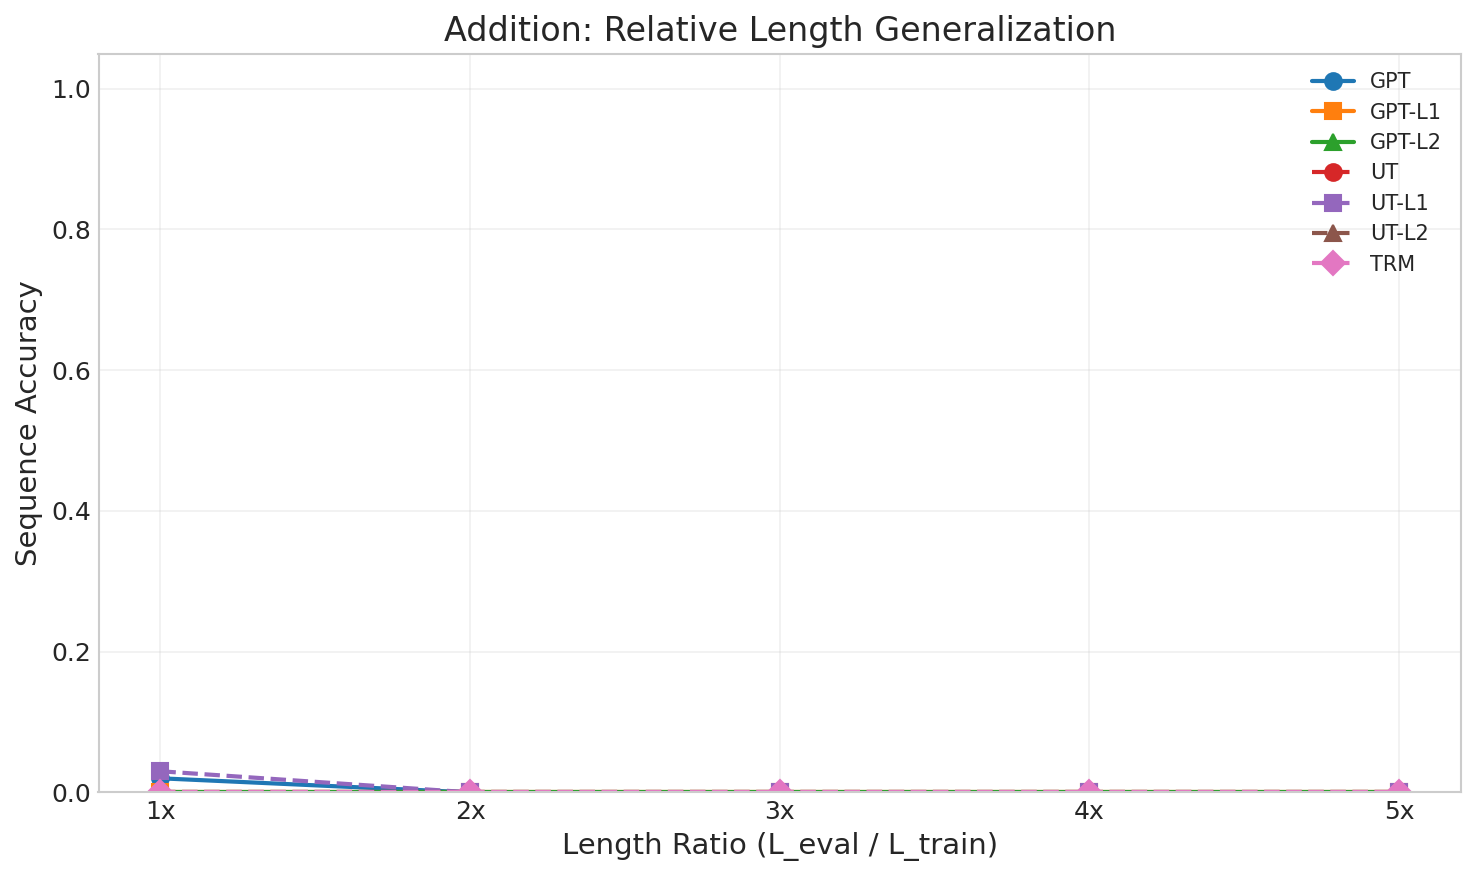

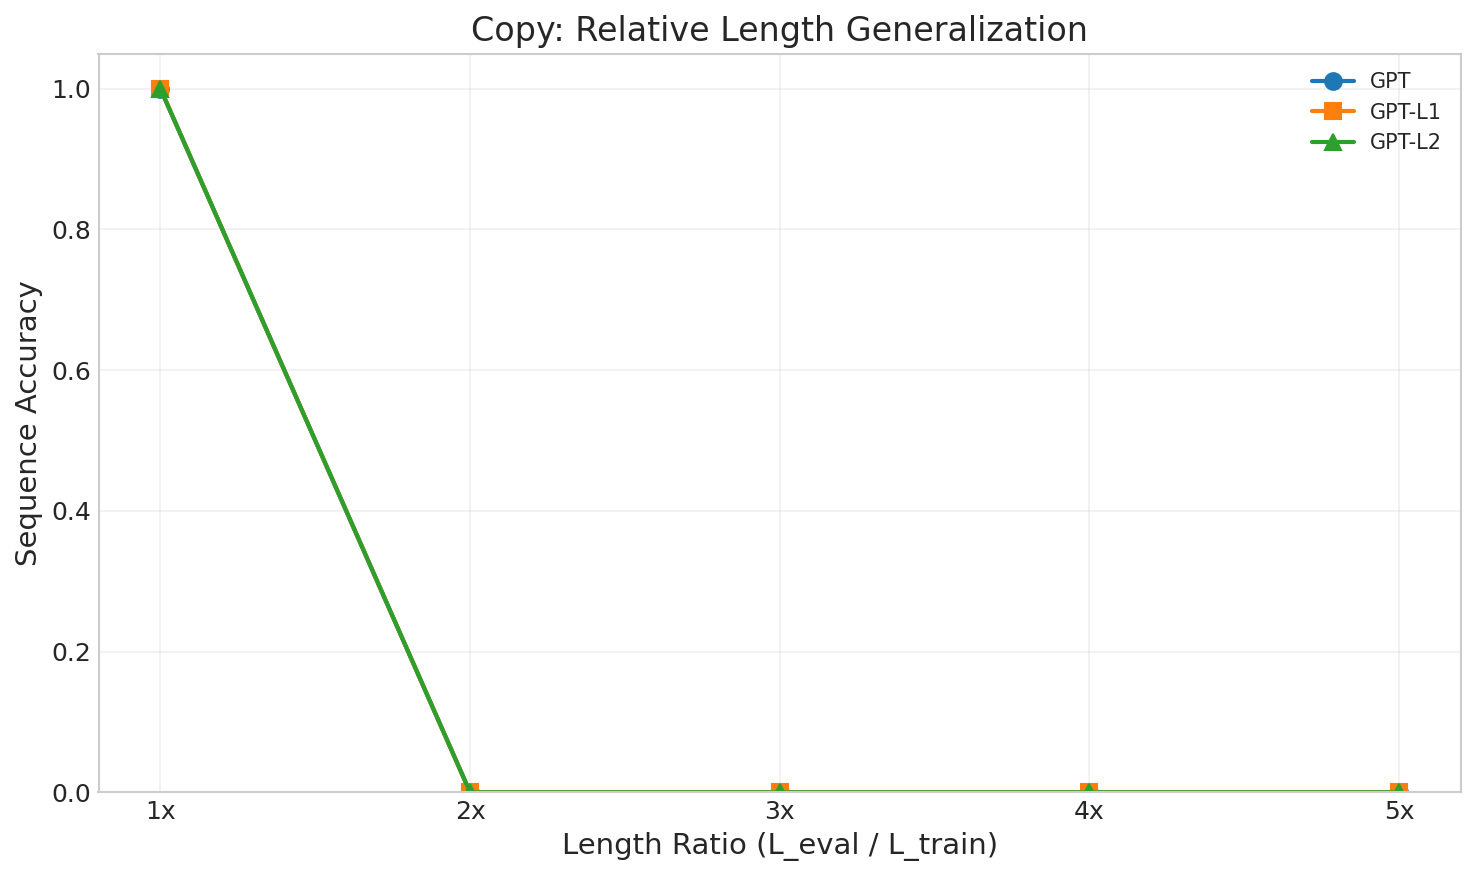

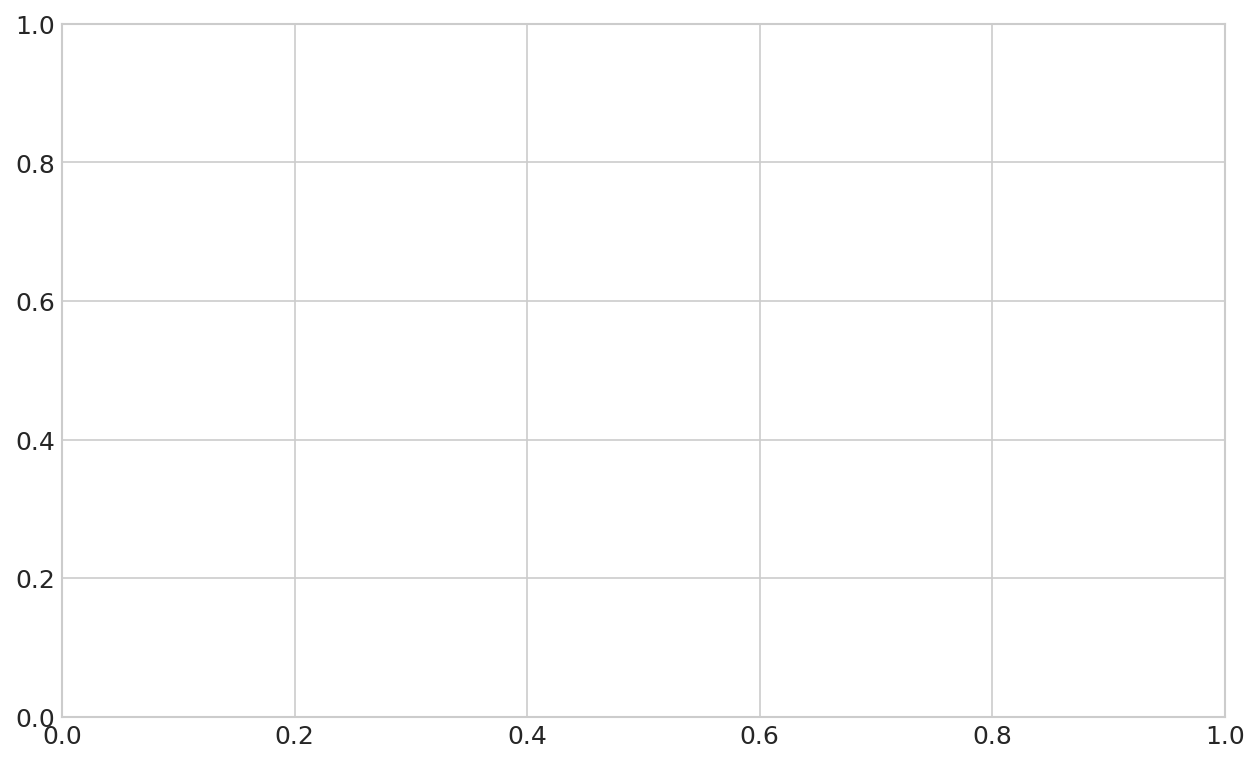

In [6]:
def plot_2_relative_length(df: pd.DataFrame, task: str, metric: str = 'seq_acc') -> plt.Figure:
    """Plot 2: Relative length ratio vs performance."""
    fig, ax = plt.subplots(figsize=(10, 6))
    
    task_df = df[df['task'] == task].copy()
    if task_df.empty:
        print(f"Warning: No data for task {task}")
        return fig
    
    train_len = task_df['train_len'].iloc[0] if 'train_len' in task_df.columns else 10
    
    eval_lengths = []
    for col in task_df.columns:
        if col.startswith('L') and col.endswith(f'_{metric}'):
            try:
                length = int(col.split('_')[0][1:])
                eval_lengths.append(length)
            except ValueError:
                pass
    eval_lengths = sorted(set(eval_lengths))
    
    for model in MODEL_ORDER:
        model_df = task_df[task_df['model'] == model]
        if model_df.empty:
            continue
        
        row = model_df.iloc[0]
        ratios, values = [], []
        
        for length in eval_lengths:
            col = f'L{length}_{metric}'
            if col in row and pd.notna(row[col]):
                ratios.append(length / train_len)
                values.append(row[col])
        
        if ratios:
            ax.plot(ratios, values,
                    color=MODEL_COLORS.get(model, 'gray'),
                    linestyle=LINE_STYLES.get(model, '-'),
                    marker=MARKERS.get(model, 'o'),
                    markersize=8, linewidth=2,
                    label=MODEL_LABELS.get(model, model))
    
    ax.set_xlabel('Length Ratio (L_eval / L_train)')
    ax.set_ylabel('Sequence Accuracy' if metric == 'seq_acc' else 'Character Accuracy')
    ax.set_title(f'{TASK_LABELS.get(task, task)}: Relative Length Generalization')
    ax.legend(loc='best', framealpha=0.9)
    ax.set_ylim(0, 1.05)
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.set_xticklabels(['1x', '2x', '3x', '4x', '5x'])
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig

for task in ['addition', 'copy', 'reverse']:
    fig = plot_2_relative_length(final_df, task, metric='seq_acc')
    plt.show()

## Plot 3:  Generalization gap

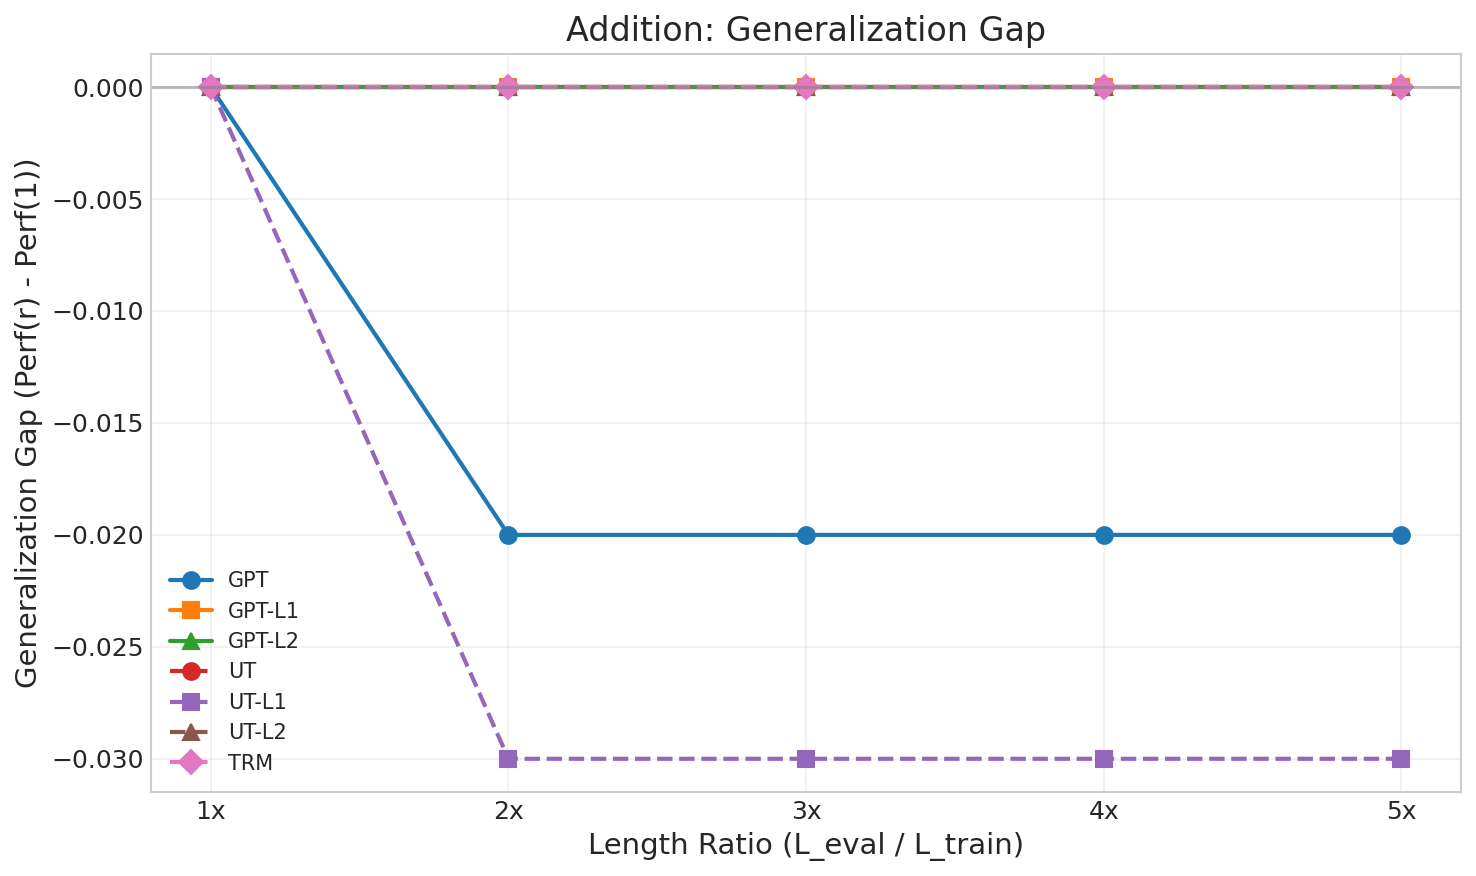

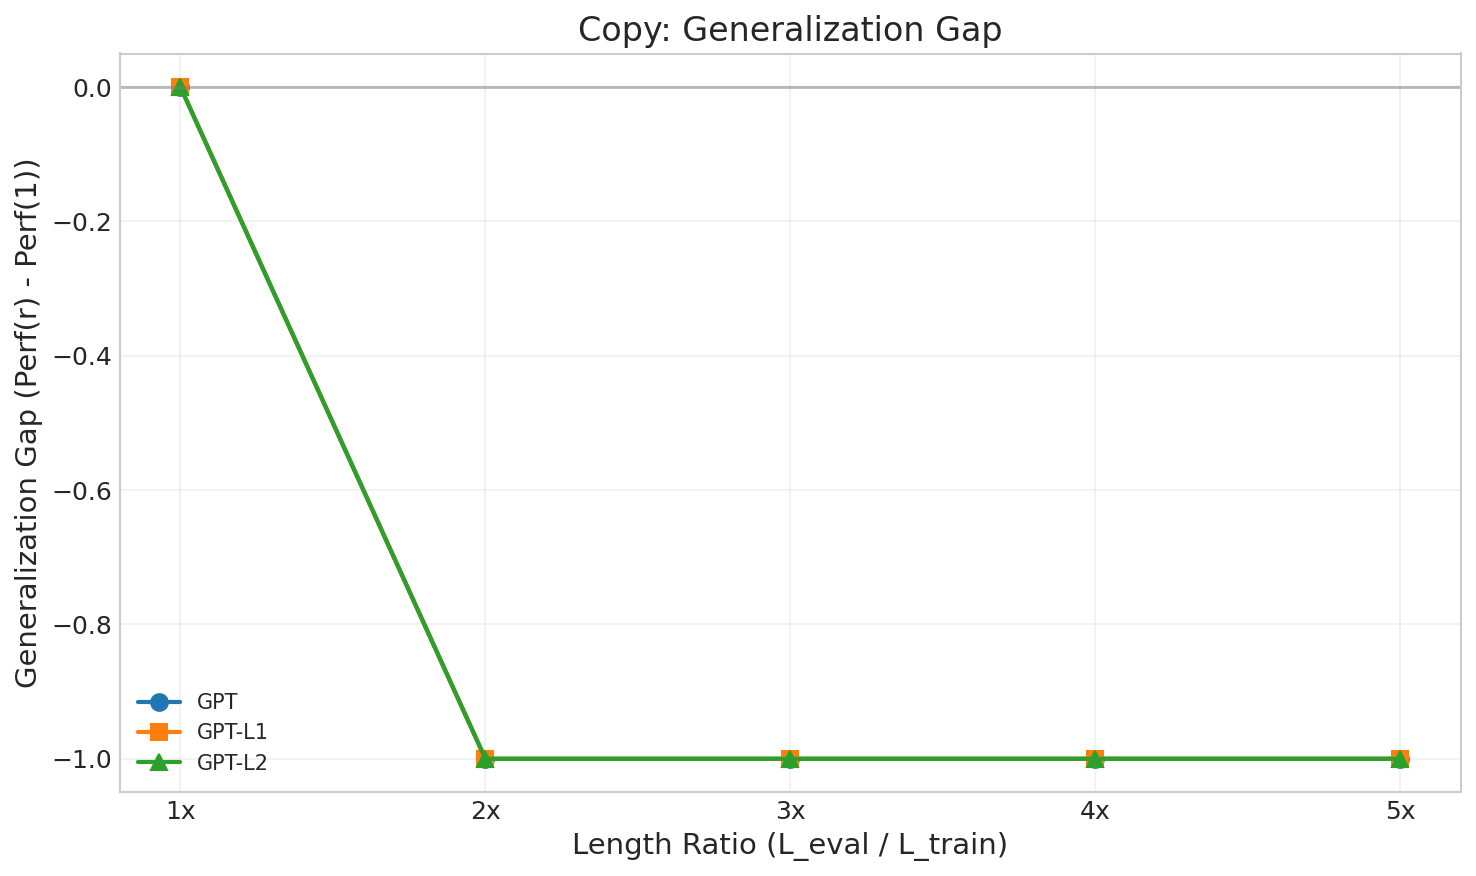

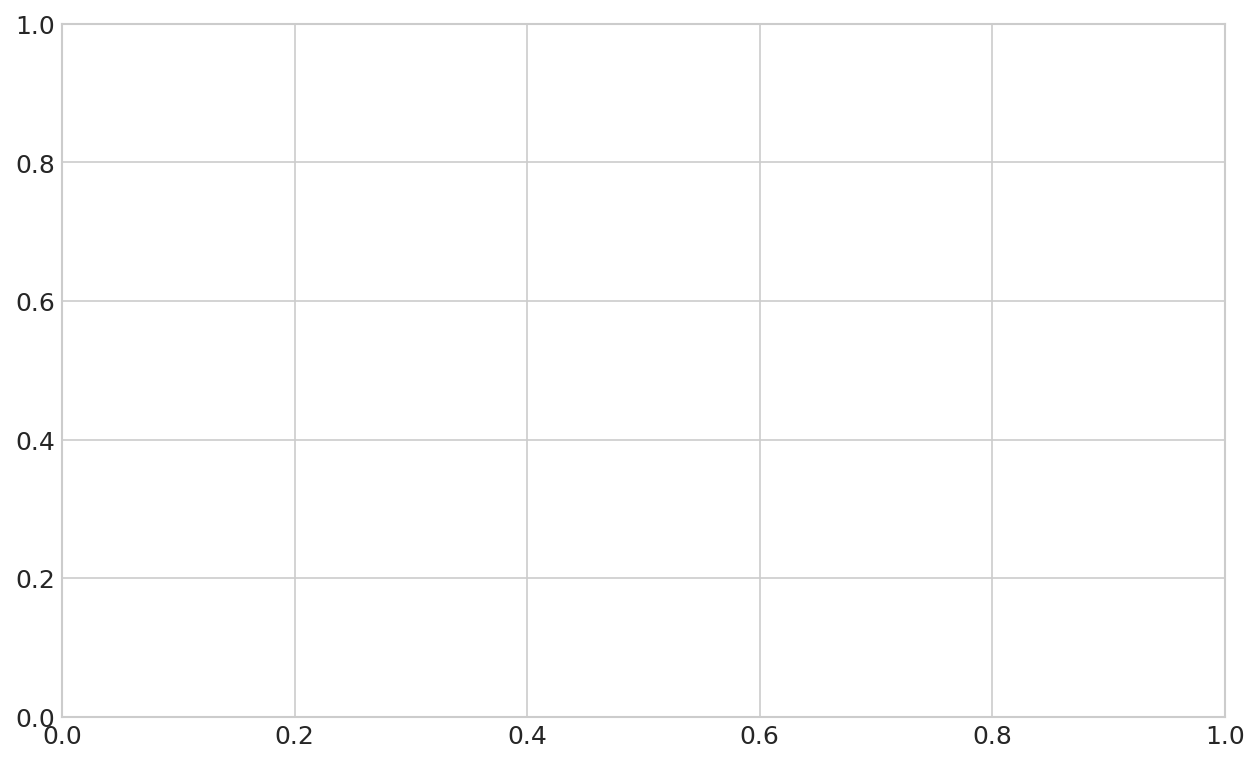

In [7]:
def plot_3_generalization_gap(df: pd.DataFrame, task: str, metric: str = 'seq_acc') -> plt.Figure:
    """Plot 3: Generalization gap vs relative length."""
    fig, ax = plt.subplots(figsize=(10, 6))
    
    task_df = df[df['task'] == task].copy()
    if task_df.empty:
        print(f"Warning: No data for task {task}")
        return fig
    
    train_len = task_df['train_len'].iloc[0] if 'train_len' in task_df.columns else 10
    
    eval_lengths = []
    for col in task_df.columns:
        if col.startswith('L') and col.endswith(f'_{metric}'):
            try:
                length = int(col.split('_')[0][1:])
                eval_lengths.append(length)
            except ValueError:
                pass
    eval_lengths = sorted(set(eval_lengths))
    
    for model in MODEL_ORDER:
        model_df = task_df[task_df['model'] == model]
        if model_df.empty:
            continue
        
        row = model_df.iloc[0]
        baseline_col = f'L{train_len}_{metric}'
        if baseline_col not in row or pd.isna(row[baseline_col]):
            continue
        baseline = row[baseline_col]
        
        ratios, gaps = [], []
        for length in eval_lengths:
            col = f'L{length}_{metric}'
            if col in row and pd.notna(row[col]):
                ratios.append(length / train_len)
                gaps.append(row[col] - baseline)
        
        if ratios:
            ax.plot(ratios, gaps,
                    color=MODEL_COLORS.get(model, 'gray'),
                    linestyle=LINE_STYLES.get(model, '-'),
                    marker=MARKERS.get(model, 'o'),
                    markersize=8, linewidth=2,
                    label=MODEL_LABELS.get(model, model))
    
    ax.set_xlabel('Length Ratio (L_eval / L_train)')
    ax.set_ylabel('Generalization Gap (Perf(r) - Perf(1))')
    ax.set_title(f'{TASK_LABELS.get(task, task)}: Generalization Gap')
    ax.legend(loc='best', framealpha=0.9)
    ax.axhline(y=0, color='gray', linestyle='-', alpha=0.5)
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.set_xticklabels(['1x', '2x', '3x', '4x', '5x'])
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig

for task in ['addition', 'copy', 'reverse']:
    fig = plot_3_generalization_gap(final_df, task, metric='seq_acc')
    plt.show()

## Training FLOPs vs Performance

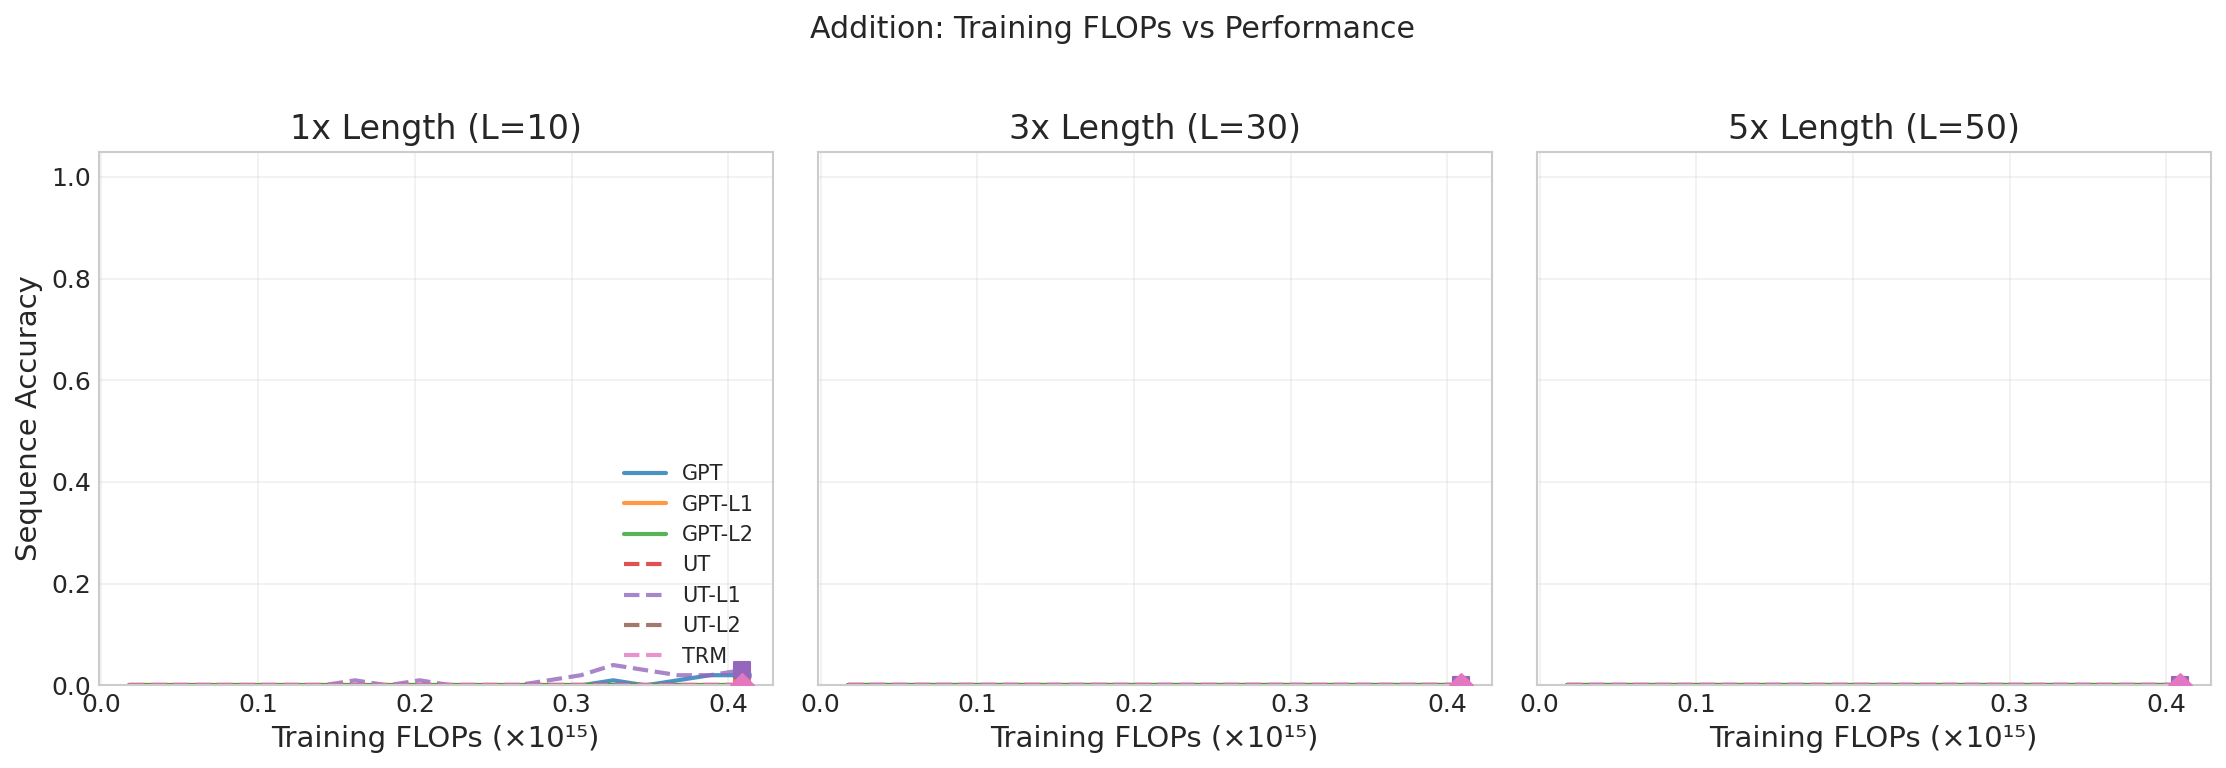

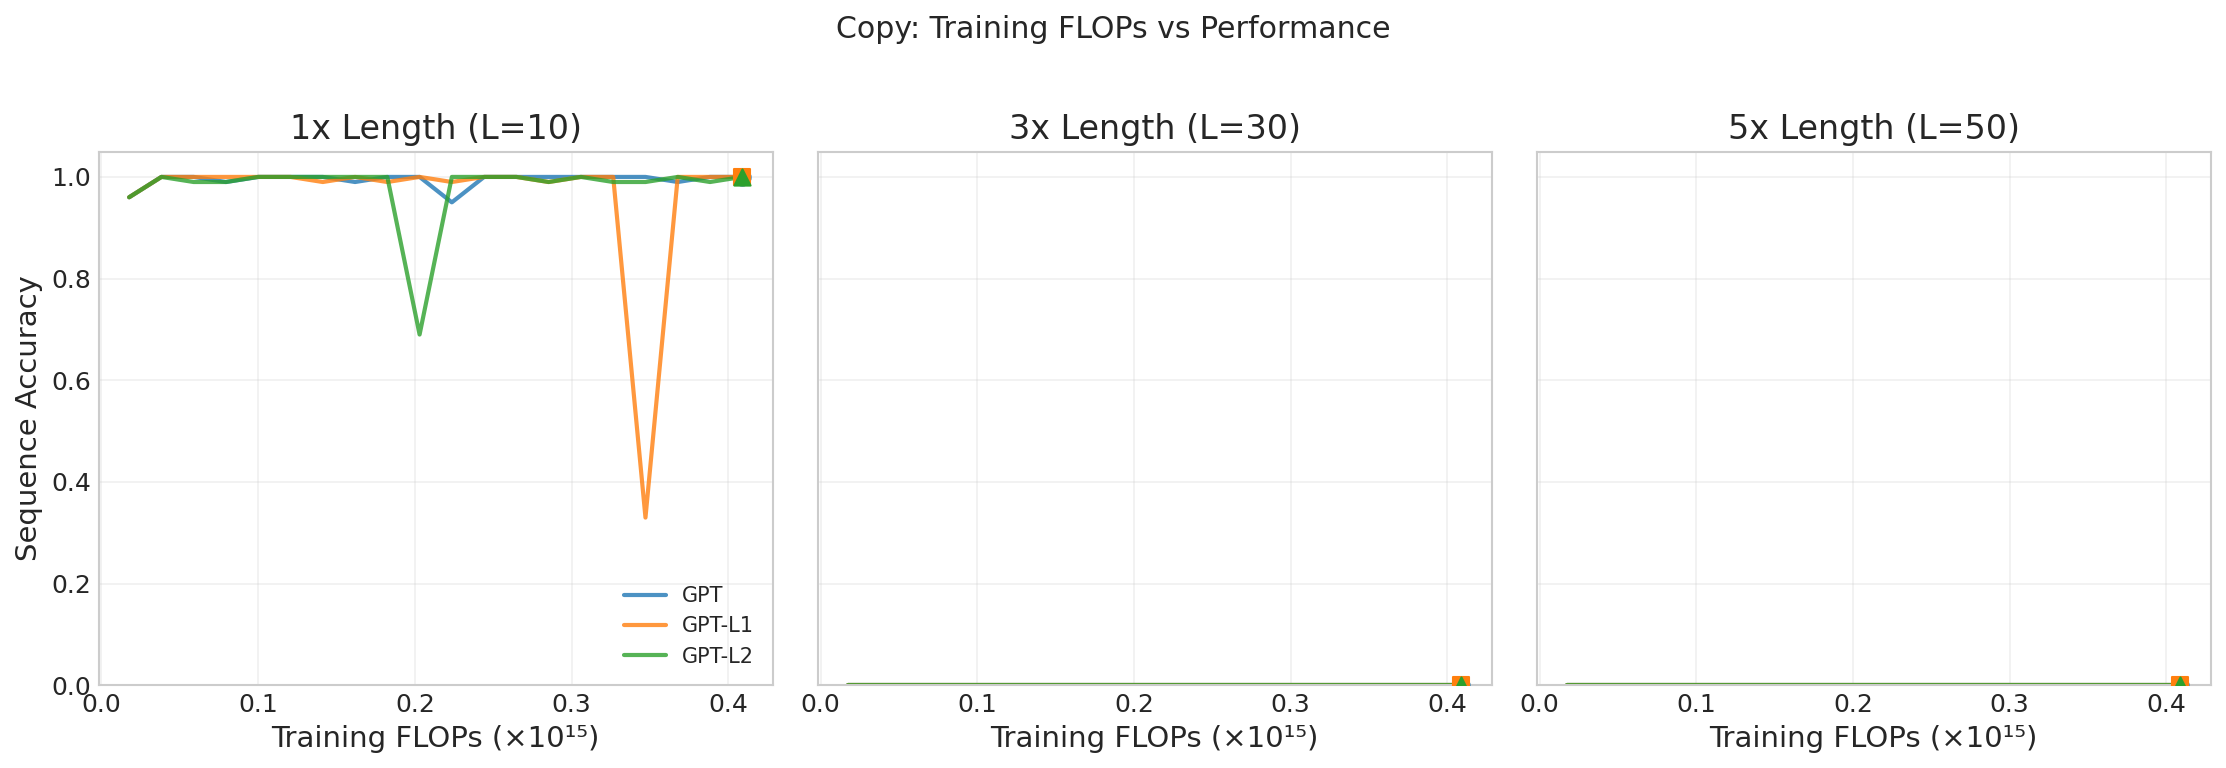

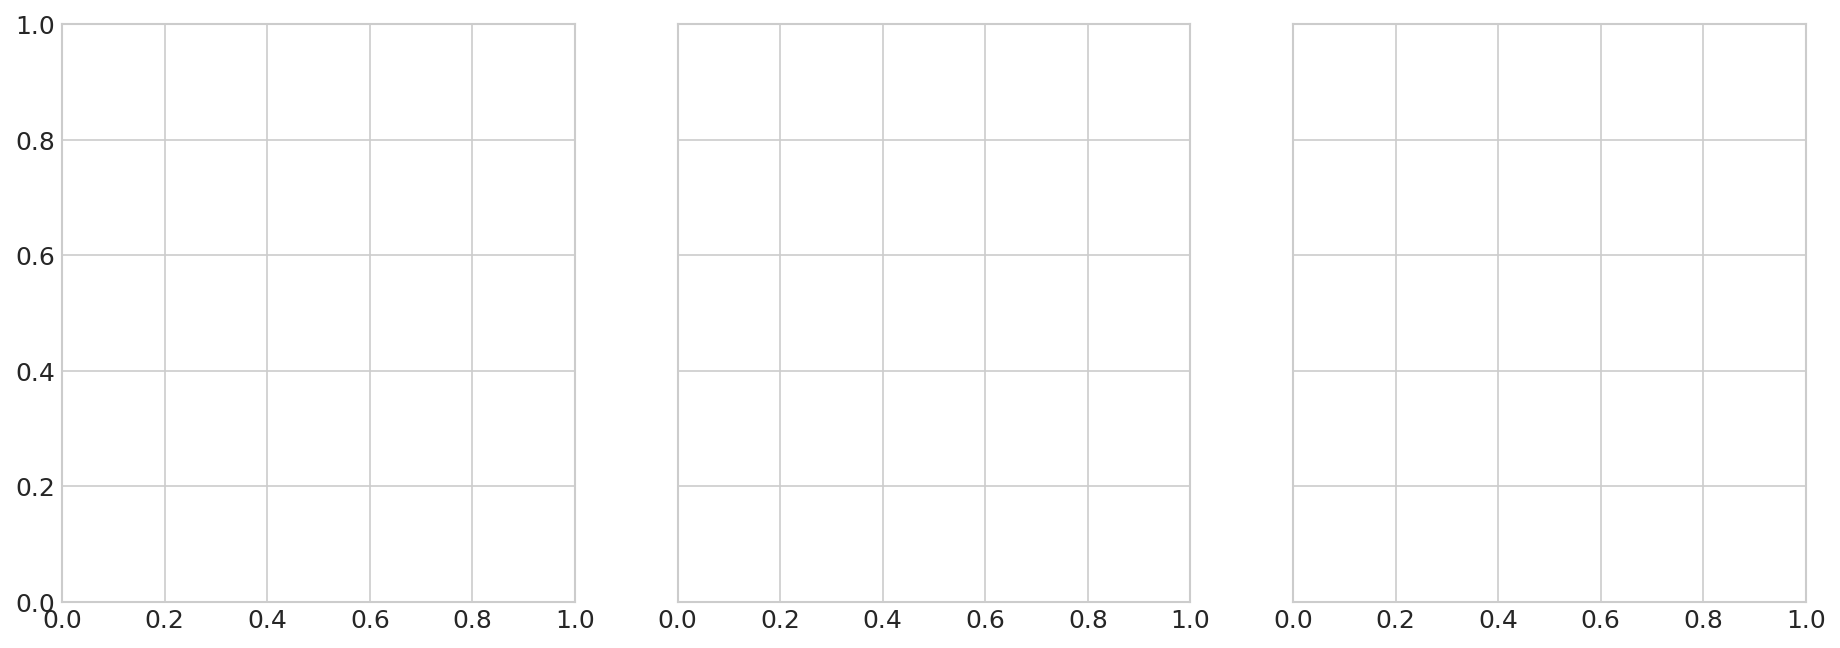

In [8]:
def plot_4_flops_performance(curves_df: pd.DataFrame, task: str, metric: str = 'seq_acc',
                             length_ratios: list = [1, 3, 5]) -> plt.Figure:
    """Plot 4: Training FLOPs vs performance at different generalization lengths."""
    n_ratios = len(length_ratios)
    fig, axes = plt.subplots(1, n_ratios, figsize=(5 * n_ratios, 5), sharey=True)
    if n_ratios == 1:
        axes = [axes]
    
    task_df = curves_df[curves_df['task'] == task].copy()
    if task_df.empty:
        print(f"Warning: No training curve data for task {task}")
        return fig
    
    train_len = task_df['train_len'].iloc[0] if 'train_len' in task_df.columns else 10
    
    for ax_idx, ratio in enumerate(length_ratios):
        ax = axes[ax_idx]
        eval_length = train_len * ratio
        metric_col = f'L{eval_length}_{metric}'
        
        for model in MODEL_ORDER:
            model_df = task_df[task_df['model'] == model].copy()
            if model_df.empty or metric_col not in model_df.columns:
                continue
            
            valid = model_df[['flops_1e15', metric_col]].dropna()
            if valid.empty:
                continue
            
            ax.plot(valid['flops_1e15'], valid[metric_col],
                    color=MODEL_COLORS.get(model, 'gray'),
                    linestyle=LINE_STYLES.get(model, '-'),
                    linewidth=2, alpha=0.8,
                    label=MODEL_LABELS.get(model, model) if ax_idx == 0 else None)
            
            ax.scatter(valid['flops_1e15'].iloc[-1], valid[metric_col].iloc[-1],
                       color=MODEL_COLORS.get(model, 'gray'),
                       marker=MARKERS.get(model, 'o'), s=60, zorder=5)
        
        ax.set_xlabel('Training FLOPs (×10¹⁵)')
        ax.set_title(f'{ratio}x Length (L={eval_length})')
        ax.set_ylim(0, 1.05)
        ax.grid(True, alpha=0.3)
        if ax_idx == 0:
            ax.set_ylabel('Sequence Accuracy' if metric == 'seq_acc' else 'Character Accuracy')
    
    axes[0].legend(loc='lower right', framealpha=0.9)
    fig.suptitle(f'{TASK_LABELS.get(task, task)}: Training FLOPs vs Performance', y=1.02)
    plt.tight_layout()
    return fig

for task in ['addition', 'copy', 'reverse']:
    fig = plot_4_flops_performance(curves_df, task, metric='seq_acc')
    plt.show()

## Plot 4b: training steps vs performance (normalized compute)

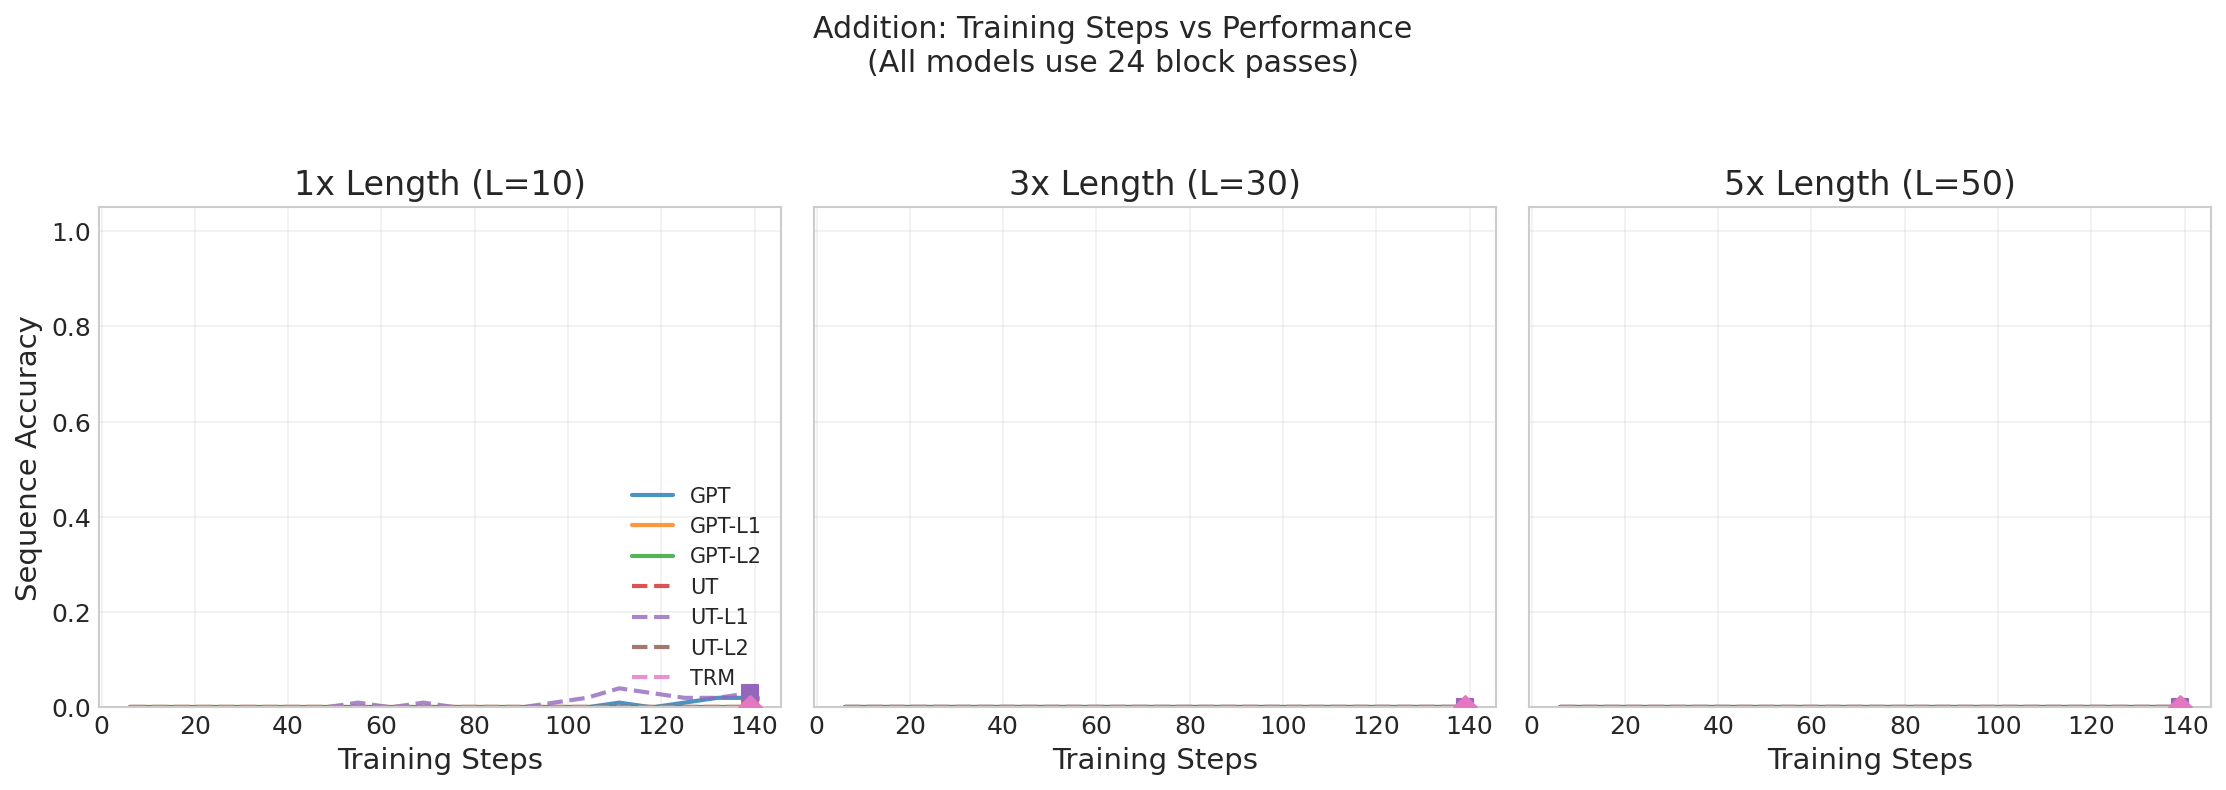

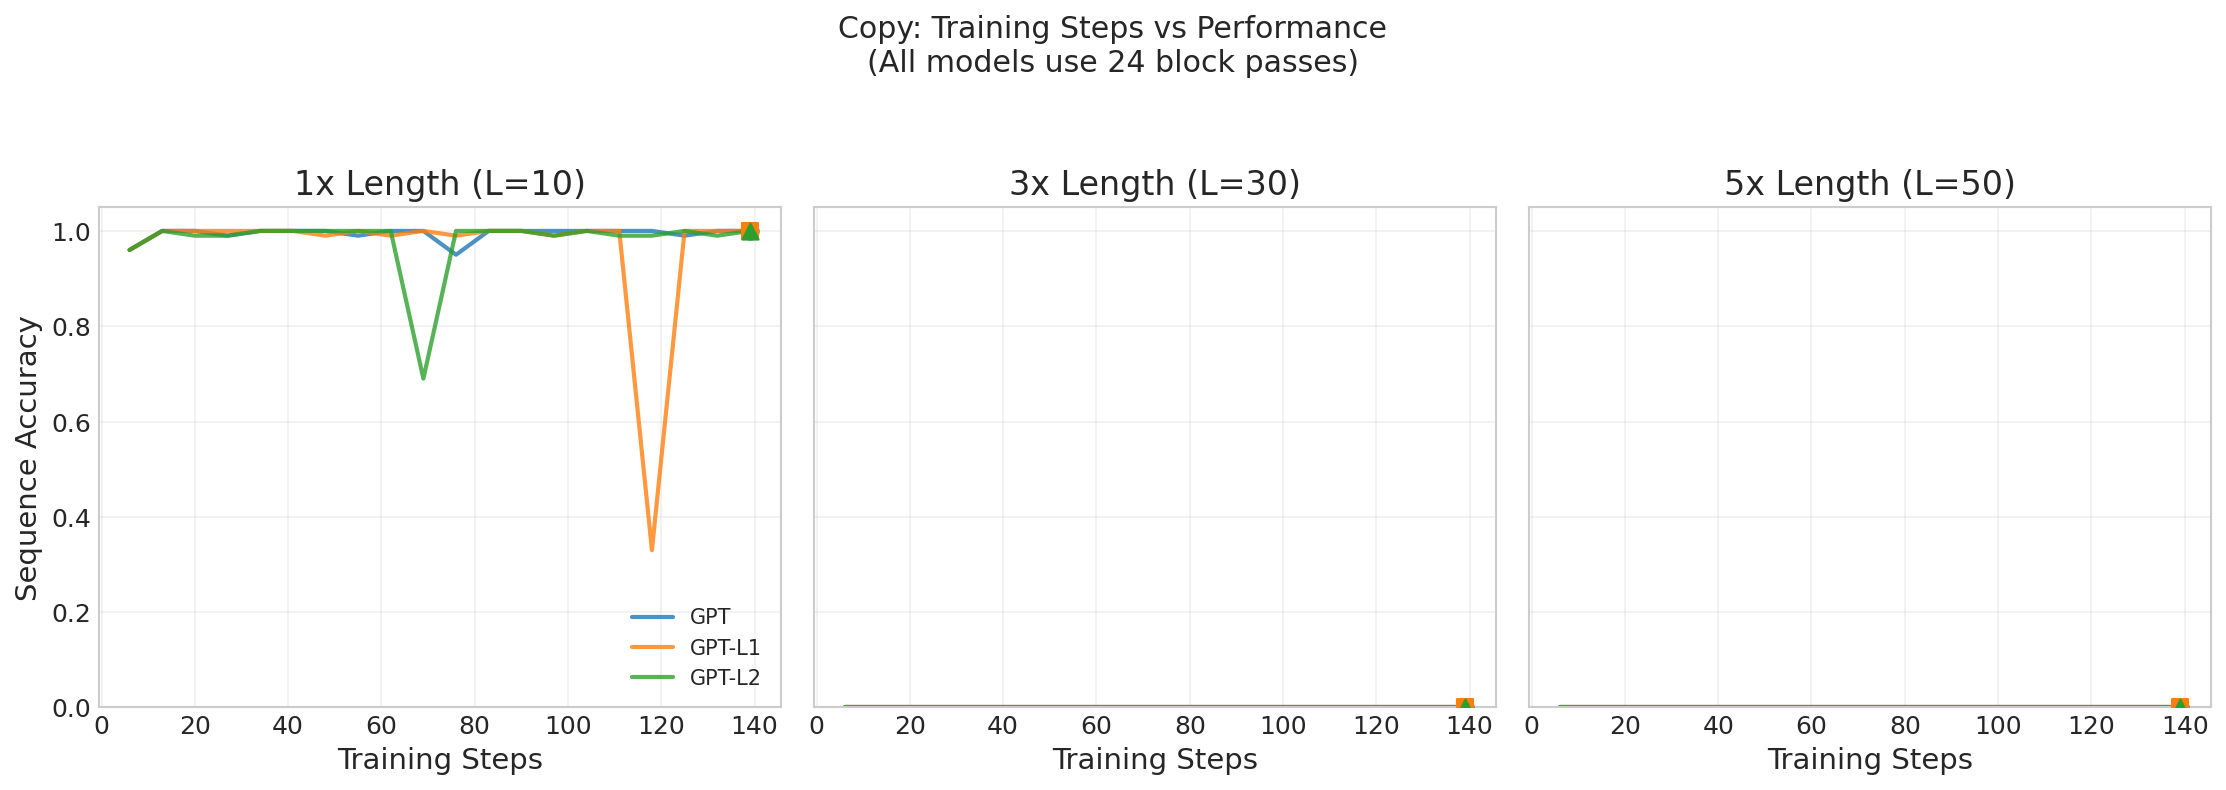

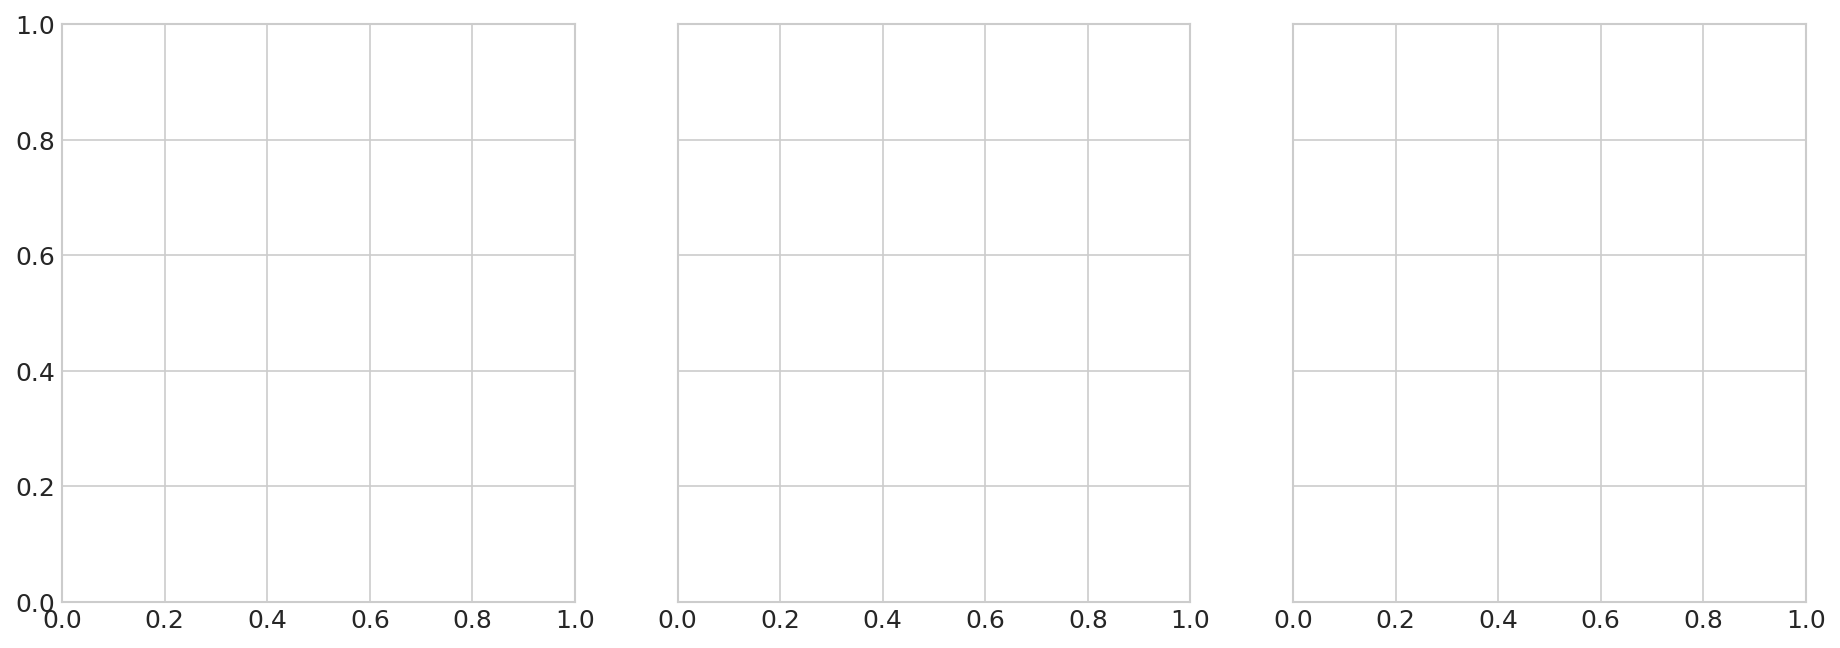

In [9]:
def plot_4_steps_performance(curves_df: pd.DataFrame, task: str, metric: str = 'seq_acc',
                             length_ratios: list = [1, 3, 5]) -> plt.Figure:
    """Plot 4 Alt: Training Steps vs performance (normalized compute comparison)."""
    n_ratios = len(length_ratios)
    fig, axes = plt.subplots(1, n_ratios, figsize=(5 * n_ratios, 5), sharey=True)
    if n_ratios == 1:
        axes = [axes]
    
    task_df = curves_df[curves_df['task'] == task].copy()
    if task_df.empty:
        print(f"Warning: No training curve data for task {task}")
        return fig
    
    train_len = task_df['train_len'].iloc[0] if 'train_len' in task_df.columns else 10
    
    for ax_idx, ratio in enumerate(length_ratios):
        ax = axes[ax_idx]
        eval_length = train_len * ratio
        metric_col = f'L{eval_length}_{metric}'
        
        for model in MODEL_ORDER:
            model_df = task_df[task_df['model'] == model].copy()
            if model_df.empty or metric_col not in model_df.columns:
                continue
            
            valid = model_df[['step', metric_col]].dropna()
            if valid.empty:
                continue
            
            ax.plot(valid['step'], valid[metric_col],
                    color=MODEL_COLORS.get(model, 'gray'),
                    linestyle=LINE_STYLES.get(model, '-'),
                    linewidth=2, alpha=0.8,
                    label=MODEL_LABELS.get(model, model) if ax_idx == 0 else None)
            
            ax.scatter(valid['step'].iloc[-1], valid[metric_col].iloc[-1],
                       color=MODEL_COLORS.get(model, 'gray'),
                       marker=MARKERS.get(model, 'o'), s=60, zorder=5)
        
        ax.set_xlabel('Training Steps')
        ax.set_title(f'{ratio}x Length (L={eval_length})')
        ax.set_ylim(0, 1.05)
        ax.grid(True, alpha=0.3)
        if ax_idx == 0:
            ax.set_ylabel('Sequence Accuracy' if metric == 'seq_acc' else 'Character Accuracy')
    
    axes[0].legend(loc='lower right', framealpha=0.9)
    compute_budget = task_df['compute_budget'].iloc[0] if 'compute_budget' in task_df.columns else '?'
    fig.suptitle(f'{TASK_LABELS.get(task, task)}: Training Steps vs Performance\n(All models use {compute_budget} block passes)', y=1.05)
    plt.tight_layout()
    return fig

for task in ['addition', 'copy', 'reverse']:
    fig = plot_4_steps_performance(curves_df, task, metric='seq_acc')
    plt.show()